In [1]:
import numpy as np
import pandas as pd

from tabularepimdl.SimpleTransition_Vec_Encode import SimpleTransition_Vec_Encode
from tabularepimdl.SimpleInfection_Vec_Encode import SimpleInfection_Vec_Encode
from tabularepimdl.BirthProcess_Vec_Encode import BirthProcess_Vec_Encode
from tabularepimdl.StateBasedDeathProcess_Vec_Encode import StateBasedDeathProcess_Vec_Encode
from tabularepimdl.WAIFWTransmission_Vec_Encode_Bincount import WAIFWTransmission_Vec_Encode_Bincount

from tabularepimdl.EpiModel_Vec_Encode1_2 import EpiModel_Vec_Encode_1_2


%matplotlib inline
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
#define global variables used by dataframes, class methods, etc.
infstate_compartments = ['S', 'I', 'R']
trans_infect_compartments =  ['S', 'I', 'R']
age_compartments_by_5 = ['0 to 4', '5 to 9', '10 to 14', '15 to 19', '20 to 24', '25 to 29', '30 to 34', '35 to 39', '40 to 44', '45 to 49', '50 to 54', '55 to 59', '60 to 64', '65 to 69', '70+']
age_compartments_by_10 = ['0 to 9', '10 to 19', '20 to 29', '30 to 39', '40 to 49', '50 to 59', '60 to 69', '70+']
start_age=0
end_age=70
age_step=5
column_to_sort = 'AgeCat'
age_struct_pop = pd.DataFrame({
    'InfState' : pd.Categorical(["S"]*15, categories=["S","I","R"]), #all categories are suscepitable
    'AgeCat': ["{} to {}".format(i, i+4) for i in range(start_age,end_age,age_step)]+["{}+".format(end_age)], #0-4, 5-9...65-69, 70+
    'N' : 100, #each group has 100 individuals
    'T': 0
})

age_struct_pop

,InfState,AgeCat,N,T
0,S,0 to 4,100,0
1,S,5 to 9,100,0
2,S,10 to 14,100,0
3,S,15 to 19,100,0
4,S,20 to 24,100,0
5,S,25 to 29,100,0
6,S,30 to 34,100,0
7,S,35 to 39,100,0
8,S,40 to 44,100,0
9,S,45 to 49,100,0


In [3]:
age_struct_pop = age_struct_pop.sample(frac=1, random_state=37).reset_index(drop=True) #row-level shuffle/row-permutation
age_struct_pop

,InfState,AgeCat,N,T
0,S,5 to 9,100,0
1,S,40 to 44,100,0
2,S,35 to 39,100,0
3,S,20 to 24,100,0
4,S,50 to 54,100,0
5,S,0 to 4,100,0
6,S,65 to 69,100,0
7,S,10 to 14,100,0
8,S,45 to 49,100,0
9,S,15 to 19,100,0


#### Create an anging population

In [4]:
aging_rules_vec = [] #the list that will hold our aging rules

#Loop over all of the categories to "60 to 65" and put them into the next age group
for i in range (start_age,end_age,age_step):
    if i < end_age-age_step:
        aging_rule = SimpleTransition_Vec_Encode(column="AgeCat",
                                from_st="{} to {}".format(i,i+4),
                                to_st="{} to {}".format(i+5,i+9),
                                rate=1/(365.25*5),
                                infstate_compartments=infstate_compartments,
                                column_categories=age_compartments_by_5) #age changing rate = 1/(5 years of 365.25 days)
    else:
        aging_rule = SimpleTransition_Vec_Encode(column="AgeCat",
                                    from_st="{} to {}".format(i,i+4),
                                    to_st="{}+".format(end_age),
                                    rate=1/(365.25*5),
                                    infstate_compartments=infstate_compartments,
                                    column_categories=age_compartments_by_5)
    aging_rules_vec.append(aging_rule) #aging_rules eventuall has end_age/age_step = 14 rules

In [5]:
agingPop_vec_mdl = EpiModel_Vec_Encode_1_2(init_state=age_struct_pop, rules=[aging_rules_vec]) #passing cur_state and rules to EpiModel

## do one year of aging.
for i in range(365):
    agingPop_vec_mdl.do_timestep(dt=1.0)
    
agingPop_vec_mdl.current_state_array

array([[  0.        ,   2.        ,  81.88428389, 365.        ],
       [  1.        ,   2.        ,  99.88627006, 365.        ],
       [  2.        ,   2.        ,  99.99441999, 365.        ],
       [  3.        ,   2.        ,  99.99978084, 365.        ],
       [  4.        ,   2.        ,  99.99999283, 365.        ],
       [  5.        ,   2.        ,  99.9999998 , 365.        ],
       [  6.        ,   2.        , 100.        , 365.        ],
       [  7.        ,   2.        , 100.        , 365.        ],
       [  8.        ,   2.        , 100.        , 365.        ],
       [  9.        ,   2.        ,  98.25441281, 365.        ],
       [ 10.        ,   2.        , 100.        , 365.        ],
       [ 11.        ,   2.        , 100.        , 365.        ],
       [ 12.        ,   2.        , 100.        , 365.        ],
       [ 13.        ,   2.        , 100.        , 365.        ],
       [ 14.        ,   2.        , 119.98083979, 365.        ]])

#### Add births and deaths

In [6]:
## Birth process...just make 10 per 1000 be born per year
simp_birth_vec = BirthProcess_Vec_Encode(rate=10/(1000*365), stochastic=False, column_to_sort=column_to_sort) #uses the yougest group as start_state_sig

##Death process...just make 20% of those in the oldest group die per year
simp_death_vec = StateBasedDeathProcess_Vec_Encode(column="AgeCat", column_states=age_compartments_by_5, target_states=["{}+".format(end_age)], rate=.2/365, stochastic=False, infstate_compartments=infstate_compartments)

In [7]:
aging_birth_death_vec_mdl = EpiModel_Vec_Encode_1_2(init_state=age_struct_pop, rules=[aging_rules_vec, [simp_birth_vec], [simp_death_vec]])
  
for i in range(365):
    aging_birth_death_vec_mdl.do_timestep(dt=1.0)

aging_birth_death_vec_mdl.current_state_array

array([[  0.        ,   2.        ,  95.46045688, 365.        ],
       [  1.        ,   2.        ,  99.9715752 , 365.        ],
       [  2.        ,   2.        ,  99.99860611, 365.        ],
       [  3.        ,   2.        ,  99.99994527, 365.        ],
       [  4.        ,   2.        ,  99.99999821, 365.        ],
       [  5.        ,   2.        ,  99.99999995, 365.        ],
       [  6.        ,   2.        , 100.        , 365.        ],
       [  7.        ,   2.        , 100.        , 365.        ],
       [  8.        ,   2.        , 100.        , 365.        ],
       [  9.        ,   2.        ,  99.56333848, 365.        ],
       [ 10.        ,   2.        , 100.        , 365.        ],
       [ 11.        ,   2.        , 100.        , 365.        ],
       [ 12.        ,   2.        , 100.        , 365.        ],
       [ 13.        ,   2.        , 100.        , 365.        ],
       [ 14.        ,   2.        ,  99.97767315, 365.        ]])

#### Putting it all togehter: an outbreak in North Carolina

In [8]:
start_age=0
end_age=70
age_step=10

nc_like_pop = pd.DataFrame({
    'InfState' : pd.Categorical(["S"]*8, ["S","I","R"]),
    'AgeCat': ["{} to {}".format(i, i+9) for i in range(start_age,end_age,age_step)]+["{}+".format(end_age)],
    'N' :[1140000, 1320000,1320000,1290000,1280000, 1280000,1185000,1175000],
    'T' : 2023 #question: do we want to assign T as an integer or float at the beginning?
})

##create one infected individual to get things started.
## Keep infect as dataframe
infect = pd.DataFrame({
    "InfState":"I",
    "AgeCat":"10 to 19",
    "N": [1],
    "T": 2023
})

add_infect = pd.concat([nc_like_pop,infect]).reset_index(drop=True)
add_infect

,InfState,AgeCat,N,T
0,S,0 to 9,1140000,2023
1,S,10 to 19,1320000,2023
2,S,20 to 29,1320000,2023
3,S,30 to 39,1290000,2023
4,S,40 to 49,1280000,2023
5,S,50 to 59,1280000,2023
6,S,60 to 69,1185000,2023
7,S,70+,1175000,2023
8,I,10 to 19,1,2023


In [9]:
add_infect = add_infect.sample(frac=1, random_state=37).reset_index(drop=True) #row-level shuffle/row-permutation
add_infect

,InfState,AgeCat,N,T
0,S,0 to 9,1140000,2023
1,S,40 to 49,1280000,2023
2,S,10 to 19,1320000,2023
3,S,70+,1175000,2023
4,I,10 to 19,1,2023
5,S,30 to 39,1290000,2023
6,S,20 to 29,1320000,2023
7,S,60 to 69,1185000,2023
8,S,50 to 59,1280000,2023


In [10]:
## Now let's create some aging rules. Let's assume that a
## a timestep is a year in this case.
nc_aging_rules_vec=[]
for i in range(start_age,end_age,age_step):
    if i < end_age-age_step:
        nc_aging_rule_vec = SimpleTransition_Vec_Encode(column="AgeCat", from_st="{} to {}".format(i,i+9), to_st="{} to {}".format(i+10,i+19), rate=1/10, infstate_compartments=infstate_compartments,
                                column_categories=age_compartments_by_10)
    else:
        nc_aging_rule_vec = SimpleTransition_Vec_Encode(column="AgeCat", from_st="{} to {}".format(i,i+9), to_st="{}+".format(end_age), rate=1/10, infstate_compartments=infstate_compartments,
                                    column_categories=age_compartments_by_10)
    
    nc_aging_rules_vec.append(nc_aging_rule_vec)

## Birth process
## New births come into the first row.
nc_birth_vec = BirthProcess_Vec_Encode(rate=7/1000, stochastic=False, column_to_sort=column_to_sort)

##Death process. Based on NC demographic data.
nc_deaths_vec = [
     StateBasedDeathProcess_Vec_Encode(column="AgeCat", column_states=age_compartments_by_10, target_states=["0 to 9"], rate=1.5/1000, stochastic=False, infstate_compartments=infstate_compartments),
     StateBasedDeathProcess_Vec_Encode(column="AgeCat", column_states=age_compartments_by_10, target_states=["10 to 19"], rate=.1/1000, stochastic=False, infstate_compartments=infstate_compartments),
     StateBasedDeathProcess_Vec_Encode(column="AgeCat", column_states=age_compartments_by_10, target_states=["20 to 29"], rate=1/1000, stochastic=False, infstate_compartments=infstate_compartments),
     StateBasedDeathProcess_Vec_Encode(column="AgeCat", column_states=age_compartments_by_10, target_states=["30 to 39"], rate=1.9/1000, stochastic=False, infstate_compartments=infstate_compartments),
     StateBasedDeathProcess_Vec_Encode(column="AgeCat", column_states=age_compartments_by_10, target_states=["40 to 49"], rate=2.7/1000, stochastic=False, infstate_compartments=infstate_compartments),
     StateBasedDeathProcess_Vec_Encode(column="AgeCat", column_states=age_compartments_by_10, target_states=["50 to 59"], rate=4.9/1000, stochastic=False, infstate_compartments=infstate_compartments),
     StateBasedDeathProcess_Vec_Encode(column="AgeCat", column_states=age_compartments_by_10, target_states=["60 to 69"], rate=10.7/1000, stochastic=False, infstate_compartments=infstate_compartments),
     StateBasedDeathProcess_Vec_Encode(column="AgeCat", column_states=age_compartments_by_10, target_states=["70+"], rate=43.9/1000, stochastic=False, infstate_compartments=infstate_compartments)
 ]

In [11]:
#Infect and Recover rules
infect_rule_vec = SimpleInfection_Vec_Encode(beta=12*26, column='InfState', s_st='S', i_st='I', inf_to='I', infstate_compartments=infstate_compartments, column_categories=trans_infect_compartments)
recover_rule_vec = SimpleTransition_Vec_Encode(column='InfState', from_st='I', to_st='R', rate=26, infstate_compartments=infstate_compartments, column_categories=trans_infect_compartments)

In [12]:
#reset infect's value
infect = pd.DataFrame({
    "InfState":"I",
    "AgeCat":"10 to 19",
    "N": [1],
    "T": 2023
})

In [13]:
##define the epidemic outbreak model
NC_outbreak_epi_vec = EpiModel_Vec_Encode_1_2(init_state=add_infect, #should this parameter be nc_like_pop if we add infect person in for loop below?
                       rules=[nc_aging_rules_vec,
                        [nc_birth_vec],
                        nc_deaths_vec,
                        [infect_rule_vec, recover_rule_vec]])


##assume 1 case is imported every timestep
for t in np.arange(0, 25, 1/52):
    #print('t=', t)
    infect.T = 2023 + t #keep T updated with delta t
    if t==0:
        NC_outbreak_epi_vec.do_timestep(dt=1/52)
        pass
    else:
        NC_outbreak_epi_vec.add_new_data_to_current_state(new_data = infect)
        NC_outbreak_epi_vec.do_timestep(dt=1/52)

In [14]:
NC_outbreak_epi_vec.current_state_array

array([[0.00000000e+00, 0.00000000e+00, 1.50584781e+03, 2.04800000e+03],
       [0.00000000e+00, 1.00000000e+00, 3.54650221e+05, 2.04800000e+03],
       [0.00000000e+00, 2.00000000e+00, 3.34994592e+05, 2.04800000e+03],
       [1.00000000e+00, 0.00000000e+00, 7.55928560e+02, 2.04800000e+03],
       [1.00000000e+00, 1.00000000e+00, 6.47531157e+05, 2.04800000e+03],
       [1.00000000e+00, 2.00000000e+00, 1.66953428e+05, 2.04800000e+03],
       [2.00000000e+00, 0.00000000e+00, 3.66049407e+02, 2.04800000e+03],
       [2.00000000e+00, 1.00000000e+00, 8.86197262e+05, 2.04800000e+03],
       [2.00000000e+00, 2.00000000e+00, 8.10056301e+04, 2.04800000e+03],
       [3.00000000e+00, 0.00000000e+00, 1.65990636e+02, 2.04800000e+03],
       [3.00000000e+00, 1.00000000e+00, 1.05675683e+06, 2.04800000e+03],
       [3.00000000e+00, 2.00000000e+00, 3.67339673e+04, 2.04800000e+03],
       [4.00000000e+00, 0.00000000e+00, 6.79629450e+01, 2.04800000e+03],
       [4.00000000e+00, 1.00000000e+00, 1.14907410e

In [15]:
NC_outbreak_result_vec = NC_outbreak_epi_vec._covnert_list_of_arrays_to_df(NC_outbreak_epi_vec._full_epi_list)

In [16]:
nc_like_pop_infected = NC_outbreak_result_vec.loc[NC_outbreak_result_vec['InfState']=="I"]
nc_like_pop_infected = nc_like_pop_infected.assign(N=np.sqrt(nc_like_pop_infected['N']))

epi_fig = px.line(nc_like_pop_infected, x="T", 
                  y="N", color="AgeCat",
                  title="NC infected population in 25 years")

epi_fig.show()

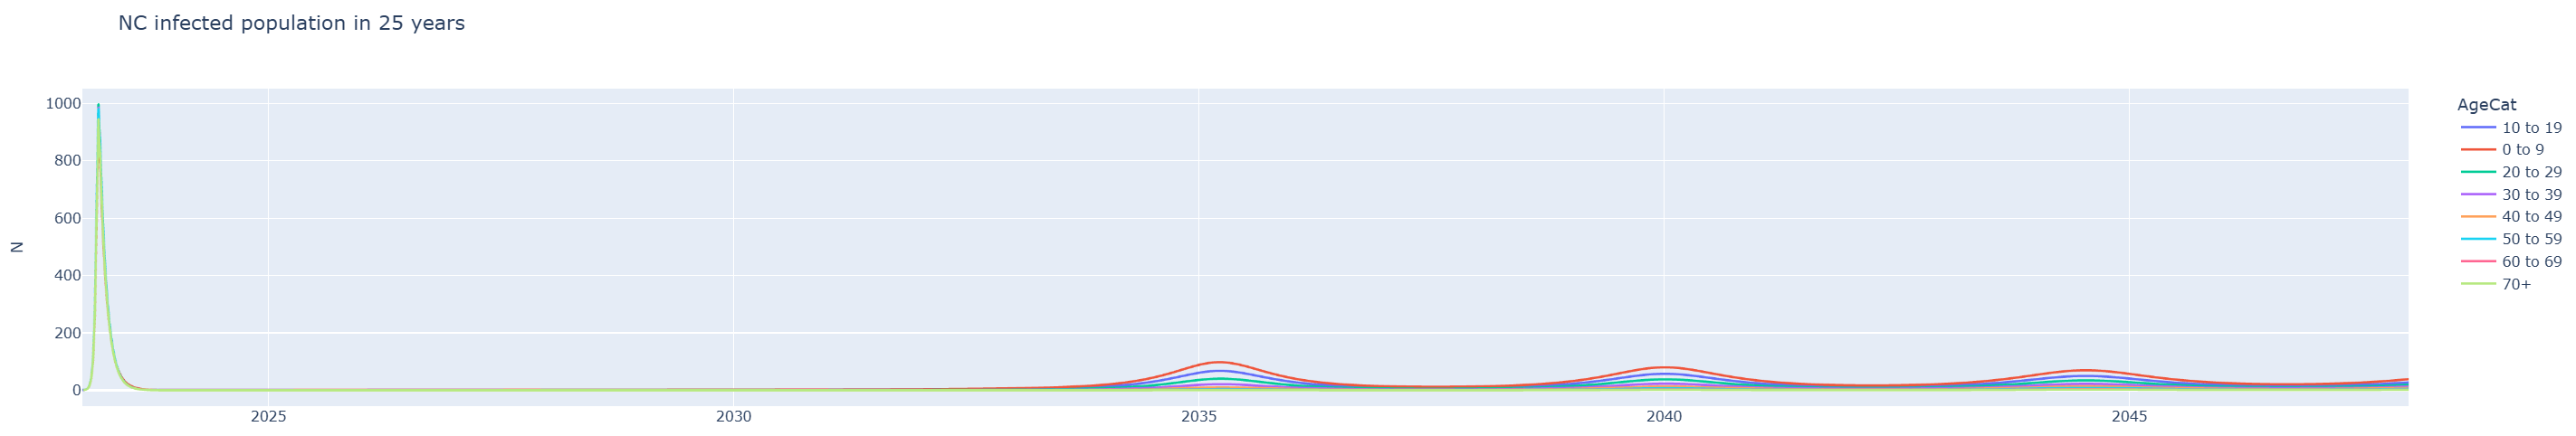

#### Age specific mixing

In [17]:
#define the WAIFW matrix
waifw = np.array([[1,1,0.5,0.5,0.5,0.5,0.25,0.25],
                  [1,1,0.5,0.5,0.5,0.5,0.25,0.25],
                  [0.5,0.5,0.25,0.25,0.25,0.25,0.5,0.5],
                  [0.5,0.5,0.25,0.25,0.25,0.25,0.5,0.5],
                  [0.5,0.5,0.25,0.25,0.25,0.25,0.5,0.5],
                  [0.5,0.5,0.25,0.25,0.25,0.25,0.5,0.5],
                  [0.25,0.25,0.5,0.5,0.5,0.5,1,1],
                  [0.25,0.25,0.5,0.5,0.5,0.5,1,1]]) 

waifw = waifw * 18 * 26 / nc_like_pop['N'].sum() 

#reset Infect
infect = pd.DataFrame({
    "InfState":"I",
    "AgeCat":"10 to 19",
    "N": [1],
    "T": 2023.0
})

In [18]:
nc_like_pop_waifw = pd.concat([nc_like_pop,infect])
nc_like_pop_waifw['AgeCat'] = pd.Categorical(nc_like_pop_waifw['AgeCat'])

In [19]:
#WAIFW rule
age_mix_vec = WAIFWTransmission_Vec_Encode_Bincount(waifw_matrix=waifw, inf_col='InfState', group_col='AgeCat', s_st='S', i_st='I', inf_to='I', stochastic=False,
                                                    infstate_compartments=infstate_compartments, group_col_all_categories=age_compartments_by_10)

In [20]:
NC_agemix_epi_vec = EpiModel_Vec_Encode_1_2(init_state=add_infect,
                       rules=[nc_aging_rules_vec,
                        [nc_birth_vec],
                        nc_deaths_vec,
                        [age_mix_vec, recover_rule_vec]])

In [21]:
for t in np.arange(0, 25, 1/52):
    infect.T = 2023 + t #keep T updated with delta t
    if t==0:
        NC_agemix_epi_vec.do_timestep(dt=1/52)
        pass
    else:
        NC_agemix_epi_vec.add_new_data_to_current_state(new_data = infect)
        NC_agemix_epi_vec.do_timestep(dt=1/52)

In [22]:
NC_agemix_epi_result_vec = NC_agemix_epi_vec._covnert_list_of_arrays_to_df(NC_agemix_epi_vec._full_epi_list)

In [23]:
NC_agemix_epi_infected_vec = NC_agemix_epi_result_vec.loc[NC_agemix_epi_result_vec['InfState']=="I"]
NC_agemix_epi_infected_vec = NC_agemix_epi_infected_vec.assign(N=np.sqrt(NC_agemix_epi_infected_vec['N'])) 
NC_agemix_epi_infected_vec

,AgeCat,InfState,N,T
1,10 to 19,I,1.000000,2023.000000
9,0 to 9,I,1.012545,2023.019231
11,10 to 19,I,1.339065,2023.019231
14,20 to 29,I,0.771476,2023.019231
17,30 to 39,I,0.761923,2023.019231
...,...,...,...,...
31188,30 to 39,I,12.011169,2048.000000
31191,40 to 49,I,8.085207,2048.000000
31194,50 to 59,I,5.068475,2048.000000
31197,60 to 69,I,2.415138,2048.000000


In [24]:
epi_fig_agemix_vec = px.line(NC_agemix_epi_infected_vec, x="T", y="N", color="AgeCat", title='NC infected population in 25 years') #add a title for the graph
epi_fig_agemix_vec.show()

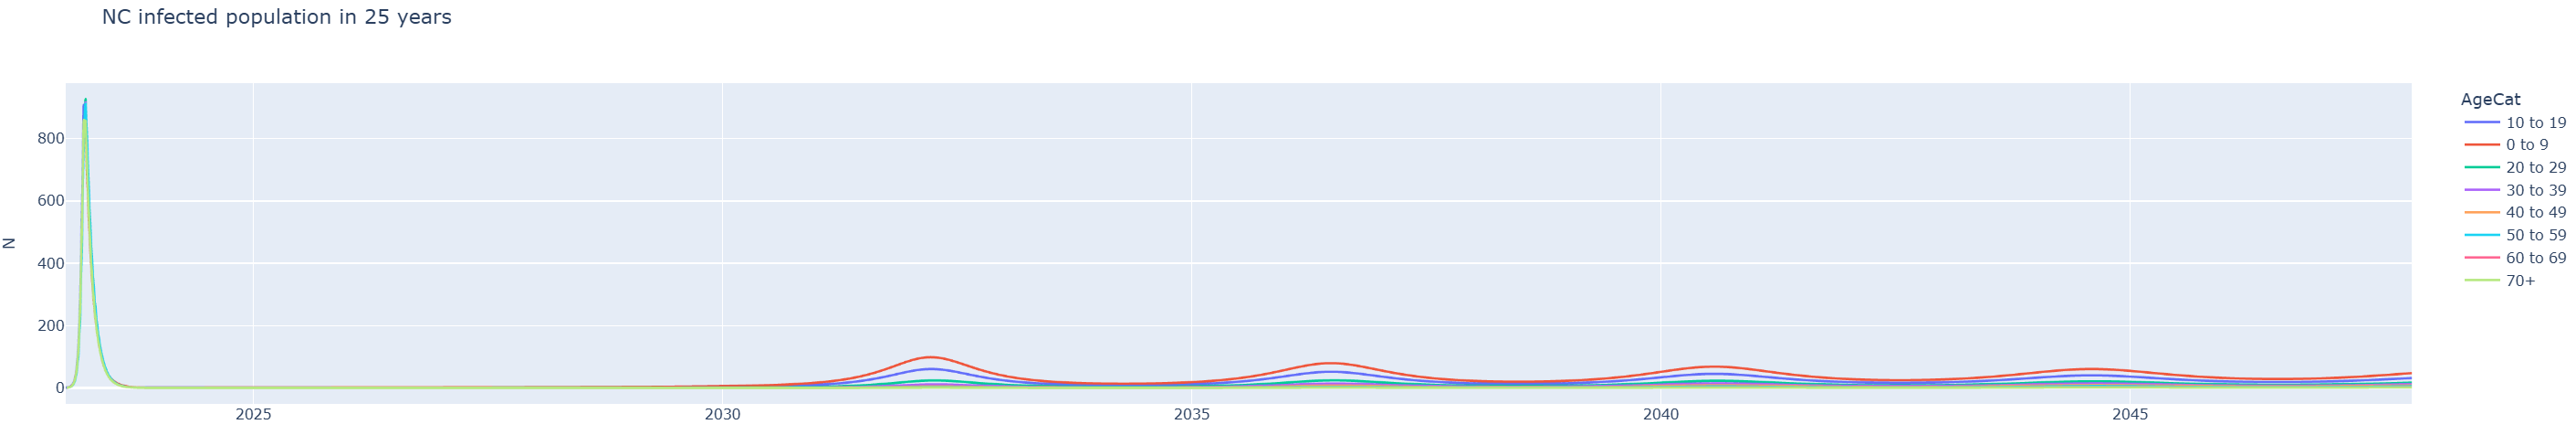